In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt

import spikeinterface as si
import spikeinterface.extractors as se
import spikeinterface.preprocessing as spre
from probeinterface import get_probe, write_probeinterface

from format_waveform_data import map_contacts_to_intan

In [2]:
''' File Paths '''
root_dir = "C:/Users/Isabel/Documents/data_temp/"

# session params
bird_id = "LMN88"
session_id = "260729"
ephys_id = "LMN88_260729_110757"
cmr = False

# path to .rhd intan file
intan_folder = f"{root_dir}{bird_id}_{session_id}/{ephys_id}/"

# kilosort directory
ks_dir = f"{intan_folder}"

# probe map
map_file_path = "Z:/Isabel/ephys/channel_maps/SILICON PROBE MAP H5_spikesort.xlsx"

# to save files
sort_dir = f"{intan_folder}/bombcell/"

In [3]:
''' load the recording and get params '''
recording = se.read_intan(f"{intan_folder}info.rhd", stream_id='0')
fs = recording.get_sampling_frequency()
probe = get_probe(manufacturer="cambridgeneurotech", probe_name="ASSY-236-H5")
contact_sort, ch_names, shank_idx = map_contacts_to_intan(probe, map_file_path)

noise_level (no parallelization):   0%|          | 0/20 [00:00<?, ?it/s]

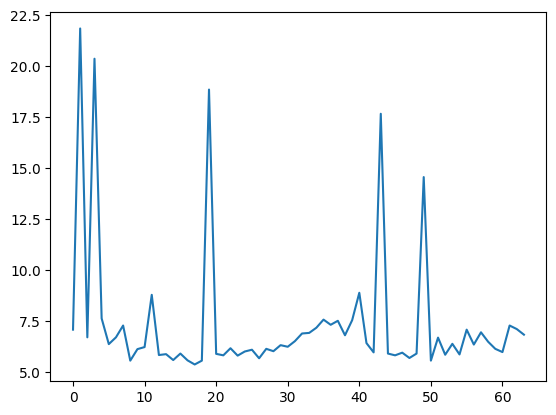

In [4]:
''' find and exclude noisy channels '''
noise_level = si.get_noise_levels(spre.common_reference(spre.highpass_filter(recording)))
plt.plot(noise_level)

In [5]:
# set noise threshold and remove noisy channels
n_channels = len(ch_names)
all_ch_idx = np.arange(n_channels)
noise_thresh = 12
keep_ch_idx = noise_level < noise_thresh
bad_channel_idx = all_ch_idx[~keep_ch_idx]
print(f"excluding {np.sum(~keep_ch_idx)} channel(s)")

excluding 5 channel(s): ['A-001' 'A-003' 'A-019' 'A-043' 'A-049']


In [6]:
# check the gain
gains = recording.get_channel_gains()
assert np.allclose(gains, gains[0]), "expected uniform gain across channels"
gain_to_uV = float(gains[0])   # typically 0.195 for Intan RHD-based systems

In [7]:
# common median reference if needed
if cmr:
    rec_cmr = spre.common_reference(recording, reference="global", operator="median")
else:
    rec_cmr = recording

In [8]:
# save as binary for KS4 and BC
rec_cmr.save(format="binary", folder=sort_dir, dtype="int16", 
             n_jobs=8, chunk_duration="1s")

write_binary_recording 
engine=process - n_jobs=8 - samples_per_chunk=30,000 - chunk_memory=3.66 MiB - total_memory=29.30 MiB - chunk_duration=1.00s


write_binary_recording (workers: 8 processes spawn):   0%|          | 0/10829 [00:00<?, ?it/s]

BinaryFolderRecording: 64 channels - 30.0kHz - 1 segments - 324,848,384 samples 
                       10,828.28s (3.01 hours) - int16 dtype - 38.72 GiB

In [10]:
bad_channel_string = ''
for b_idx in bad_channel_idx:
    bad_channel_string = bad_channel_string + f'{b_idx}, '

print(f"Binary ready for native Kilosort4 GUI: {sort_dir}/traces_cached_seg0.raw")
print(f"Channel index to exlude: [{bad_channel_string}], fs: {fs}, gain_to_uV: {gain_to_uV}")

Binary ready for native Kilosort4 GUI: C:/Users/Isabel/Documents/data_temp/LMN88_260729/LMN88_260729_110757//bombcell//traces_cached_seg0.raw
Channel index to exlude: [1, 3, 19, 43, 49, ], fs: 30000.0, gain_to_uV: 0.195
